### Funções Auxiliares

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import RobustScaler

In [33]:
def filter_valid_ratings(df: pd.DataFrame) -> pd.DataFrame:
    tamanho_original = len(df)
    
    df = df.dropna(subset=["geek_rating"]).copy()

    n_zero = (df["geek_rating"] == 0).sum()
    df = df[df["geek_rating"] > 0].copy()
    
    print(f"[filter_ratings] Linhas reduzidas de {tamanho_original} para {len(df)} (apenas com rating válido).")
    print(f"[filter_ratings] {n_zero:,} linha(s) com geek_rating == 0 removidas (sem votos suficientes no BGG, não é rating real).")
    return df

In [34]:
def clean_numeric_columns(df):
    num_cols = ["geek_rating"]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
 
    print(f"[numeric] {num_cols} convertidos")
    return df

In [35]:
def clean_num_players(df: pd.DataFrame) -> pd.DataFrame:
    def parse_players(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["num_players"].apply(parse_players)
    df["min_players"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_players"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["num_players"], inplace=True)
    print("[num_players] min_players / max_players extraídos")
    return df

In [36]:
def clean_play_time(df: pd.DataFrame) -> pd.DataFrame:
    def parse_time(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["play_time"].apply(parse_time)
    df["min_time"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_time"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["play_time"], inplace=True)
    print("[play_time] min_time / max_time extraídos")
    return df

In [37]:
def clean_suggested_age(df: pd.DataFrame) -> pd.DataFrame:
    df["min_suggested_age"] = (
        df["min_suggested_age"]
        .str.replace(r"\D", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )
    print(f"[age] suggested_age — NaN: {df['min_suggested_age'].isna().sum():,}")
    return df

In [38]:
def clean_complexity(df: pd.DataFrame) -> pd.DataFrame:
    df["complexity"] = (
        df["complexity"]
        .str.extract(r"([\d.]+)\s*/\s*5")[0]
        .pipe(pd.to_numeric, errors="coerce")
    )
    print(f"[complexity] NaN: {df['complexity'].isna().sum():,}")
    return df

In [39]:
def normalize_list_columns(df: pd.DataFrame) -> pd.DataFrame:
    LIST_COLUMNS = ["categories", "mechanisms"]
    
    for col in LIST_COLUMNS:
        df[col] = df[col].apply(
            lambda x: [item.strip() for item in str(x).split(" / ")]
            if pd.notna(x) else []
        )
    print(f"[lists] {LIST_COLUMNS} convertidos para listas")
    return df

In [40]:
def clean_publishers(df: pd.DataFrame) -> pd.DataFrame:
    if "publishers" in df.columns:
        # Pega somente a primeira publisher, separando no primeiro " / "
        df["publishers"] = df["publishers"].apply(
            lambda x: str(x).split(" / ")[0].strip() if pd.notna(x) else pd.NA
        )
        print("[publishers] Primeira publisher extraída")
    return df

In [41]:
def clean_relationships(df: pd.DataFrame) -> pd.DataFrame:
    if "relationship" in df.columns:
        mask_expansion = df["relationship"].str.contains("Expansion for", na=False, case=False)
        
        df = df[~(mask_expansion) | df["relationship"].isna()].copy()
        
        df.drop(columns=["relationship"], inplace=True) 
        
        print("[relationship] Linhas com 'Expansion for' removidas")
    return df

In [42]:
def drop_unnecessary_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = ["artists", "developer", "rank", "designers", "avg_rating", "price", "num_voters", "year"]
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    
    if existing_cols:
        df.drop(columns=existing_cols, inplace=True)
        print(f"[drop] Colunas removidas: {existing_cols}")
    return df

In [43]:
def drop_falha_rows(df: pd.DataFrame) -> pd.DataFrame:
    mask = df.apply(
        lambda col: col.astype(str).str.contains(r'\bFalha\b', case=False, na=False)
    ).any(axis=1)

    n_removed = mask.sum()
    df = df[~mask].copy()
    print(f"[drop_falha] {n_removed:,} linha(s) contendo 'Falha' removida(s).")
    return df

In [44]:
def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df['has_description'] = df['description'].notna().astype(int)
    df['description'] = df['description'].fillna("missing_description")
    
    if df['complexity'].isna().sum() > 0:
        df['complexity_is_missing'] = df['complexity'].isna().astype(int)
        df['complexity'] = df['complexity'].fillna(df['complexity'].median())

    if df['min_suggested_age'].isna().sum() > 0:
        df['min_suggested_age_is_missing'] = df['min_suggested_age'].isna().astype(int)
    
    if df['min_time'].isna().sum() > 0:
        df['time_is_missing'] = df['min_time'].isna().astype(int)


    discrete_cols = ['min_suggested_age', 'min_players', 'max_players', 'min_time', 'max_time']
    for col in discrete_cols:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].median()).astype('int64')

    print("[Imputação] Valores nulos preenchidos de forma otimizada.")
    return df

In [45]:
def extract_main_publisher(df: pd.DataFrame) -> pd.DataFrame:
    df['publishers'] = (
        df['publishers']
        .astype(str)
        .str.split(" / ")
        .str[0]
        .str.strip()
    )
    print("[Publishers] Extraída a publisher principal (primeiro nome antes da '/').")
    return df

In [46]:
def encode_publishers(df: pd.DataFrame) -> pd.DataFrame:
    pub_freq = df['publishers'].value_counts(normalize=True)
    
    df['publisher_freq'] = df['publishers'].map(pub_freq)
    
    df.drop(columns=['publishers'], inplace=True)
    print("[Encoder] Publishers convertidos para frequência.")
    return df

In [47]:
def drop_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    n_antes = len(df)
    df = df.drop_duplicates().copy()
    n_removidas = n_antes - len(df)
    print(f"[duplicates] {n_removidas:,} linha(s) duplicada(s) removida(s).")
    return df

In [48]:
def fix_min_max_inconsistencies(df: pd.DataFrame) -> pd.DataFrame:

    pares = [("min_players", "max_players"), ("min_time", "max_time")]

    for min_col, max_col in pares:
        mask = df[min_col] > df[max_col]
        n_fix = mask.sum()
        if n_fix > 0:
            df.loc[mask, [min_col, max_col]] = df.loc[mask, [max_col, min_col]].values
        print(f"[min_max] {min_col}/{max_col}: {n_fix:,} linha(s) com min > max corrigida(s) (valores trocados).")

    return df

In [49]:
def remove_extreme_outliers(df: pd.DataFrame, cols: list, max_pct_removal: float = 0.02) -> pd.DataFrame:
    tamanho_original = len(df)
    mask_total_outlier = pd.Series(False, index=df.index)

    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        limite_inferior = q1 - 3 * iqr
        limite_superior = q3 + 3 * iqr

        mask_col = (df[col] < limite_inferior) | (df[col] > limite_superior)
        pct_col = mask_col.sum() / tamanho_original

        if pct_col < max_pct_removal:
            mask_total_outlier |= mask_col
            print(f"[outliers] '{col}': {mask_col.sum():,} outlier(s) extremo(s) ({pct_col*100:.2f}%) marcado(s) para remoção.")
        else:
            print(f"[outliers] '{col}': {mask_col.sum():,} outlier(s) extremo(s) ({pct_col*100:.2f}%) ULTRAPASSA {max_pct_removal*100:.0f}% — mantidos (não removidos).")

    df = df[~mask_total_outlier].copy()
    print(f"[outliers] Total: {tamanho_original:,} -> {len(df):,} linhas ({tamanho_original - len(df):,} removidas, {(tamanho_original - len(df))/tamanho_original*100:.2f}%).")

    return df

In [50]:
def run_pipeline(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    
    df = (df.pipe(drop_duplicate_rows)
            .pipe(drop_unnecessary_columns)
            .pipe(filter_valid_ratings)
            .pipe(clean_numeric_columns)
            .pipe(clean_num_players)
            .pipe(clean_play_time)
            .pipe(clean_suggested_age)
            .pipe(clean_complexity)
            .pipe(clean_publishers)
            .pipe(clean_relationships)
            .pipe(drop_falha_rows)
            .pipe(extract_main_publisher)
            .pipe(normalize_list_columns)
            .pipe(impute_missing_values)
            .pipe(encode_publishers)
            .pipe(fix_min_max_inconsistencies)
            .pipe(remove_extreme_outliers, cols=['max_players', 'max_time', 'min_time'])
            )
    
    return df

### Tratamento

In [51]:
csv_path = "bgg_dataset.csv"
df_tratado = run_pipeline(csv_path)

[duplicates] 0 linha(s) duplicada(s) removida(s).
[drop] Colunas removidas: ['artists', 'developer', 'rank', 'designers', 'avg_rating', 'price', 'num_voters', 'year']
[filter_ratings] Linhas reduzidas de 153148 para 35734 (apenas com rating válido).
[filter_ratings] 63 linha(s) com geek_rating == 0 removidas (sem votos suficientes no BGG, não é rating real).
[numeric] ['geek_rating'] convertidos
[num_players] min_players / max_players extraídos
[play_time] min_time / max_time extraídos
[age] suggested_age — NaN: 2,815
[complexity] NaN: 37
[publishers] Primeira publisher extraída
[relationship] Linhas com 'Expansion for' removidas
[drop_falha] 37 linha(s) contendo 'Falha' removida(s).
[Publishers] Extraída a publisher principal (primeiro nome antes da '/').
[lists] ['categories', 'mechanisms'] convertidos para listas
[Imputação] Valores nulos preenchidos de forma otimizada.
[Encoder] Publishers convertidos para frequência.
[min_max] min_players/max_players: 0 linha(s) com min > max corr

In [52]:
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 25367 entries, 0 to 151828
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   title                         25367 non-null  str    
 1   description                   25367 non-null  str    
 2   geek_rating                   25367 non-null  float64
 3   min_suggested_age             25367 non-null  int64  
 4   complexity                    25367 non-null  float64
 5   categories                    25367 non-null  object 
 6   mechanisms                    25367 non-null  object 
 7   min_players                   25367 non-null  int64  
 8   max_players                   25367 non-null  int64  
 9   min_time                      25367 non-null  int64  
 10  max_time                      25367 non-null  int64  
 11  has_description               25367 non-null  int64  
 12  min_suggested_age_is_missing  25367 non-null  int64  
 13  time_is_missing 

In [53]:
df_tratado.head()

,title,description,geek_rating,min_suggested_age,complexity,categories,mechanisms,min_players,max_players,min_time,max_time,has_description,min_suggested_age_is_missing,time_is_missing,publisher_freq
0,Brass: Birmingham,"Build networks, grow industries, and navigate ...",8.394,14,3.86,"[Age of Reason, Economic, Industry, Manufactur...","[Chaining, End Game Bonuses, Hand Management, ...",2,4,60,120,1,0,0,0.003035
1,Ark Nova,"Plan and build a modern, scientifically manage...",8.354,14,3.80,"[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov...",1,4,90,150,1,0,0,0.001897
2,Pandemic Legacy: Season 1,Mutating diseases are spreading around the wor...,8.345,13,2.83,"[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem...",2,4,60,60,1,0,0,0.004932
3,Gloomhaven,Vanquish monsters with strategic cardplay. Ful...,8.296,14,3.92,"[Adventure, Exploration, Fantasy, Fighting, Mi...","[Action Queue, Action Retrieval, Campaign, Bat...",1,4,60,120,1,0,0,0.001517
4,Dune: Imperium – Uprising,"Deploy agents, build your deck, and engage in ...",8.244,13,3.52,"[Movies, TV, Radio theme, Novel-based, Science...","[Automatic Resource Growth, Card Play Conflict...",1,6,60,120,1,0,0,0.001517


In [54]:
def analyze_distribution(df: pd.DataFrame, col_name: str):
    exploded = df[col_name].explode().dropna()
    
    counts = exploded.value_counts()
    
    perc = counts / len(exploded) * 100
    cum_perc = perc.cumsum()

    resumo = pd.DataFrame({
        'Frequencia': counts,
        'Porcentagem (%)': perc.round(2),
        'Acumulada (%)': cum_perc.round(2)
    })
    
    print(f"\n--- Distribuição da coluna: {col_name.upper()} ---")
    print(f"Total de itens únicos: {len(counts)}")
    print("\nTop 10 mais frequentes:")
    print(resumo.head(10))
    print("\nÚltimos 5 (menos frequentes):")
    print(resumo.tail(5))
    
    return resumo

resumo_cat = analyze_distribution(df_tratado, "categories")
resumo_mec = analyze_distribution(df_tratado, "mechanisms")


--- Distribuição da coluna: CATEGORIES ---
Total de itens únicos: 91

Top 10 mais frequentes:
                 Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                 
Card Game               848            10.53          10.53
Wargame                 466             5.79          16.32
Fantasy                 456             5.66          21.98
Science Fiction         272             3.38          25.36
Fighting                246             3.06          28.42
Dice                    243             3.02          31.43
Economic                240             2.98          34.41
Adventure               231             2.87          37.28
Animals                 230             2.86          40.14
Party Game              212             2.63          42.77

Últimos 5 (menos frequentes):
                            Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                            
American Rev

In [55]:
print(resumo_cat.head(45)) # 49.45% das categorias representam 85.20% dos jogos

                    Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                    
Card Game                  848            10.53          10.53
Wargame                    466             5.79          16.32
Fantasy                    456             5.66          21.98
Science Fiction            272             3.38          25.36
Fighting                   246             3.06          28.42
Dice                       243             3.02          31.43
Economic                   240             2.98          34.41
Adventure                  231             2.87          37.28
Animals                    230             2.86          40.14
Party Game                 212             2.63          42.77
Exploration                194             2.41          45.18
Deduction                  169             2.10          47.28
Miniatures                 158             1.96          49.24
Medieval                   149             1.85        

In [56]:
print(resumo_mec.head(70)) # 34.63% das mecânicas representam 84.14% dos jogos

                        Frequencia  Porcentagem (%)  Acumulada (%)
mechanisms                                                        
Dice Rolling                   812             5.82           5.82
Hand Management                730             5.23          11.05
Variable Player Powers         526             3.77          14.82
Set Collection                 451             3.23          18.05
Solo                           435             3.12          21.17
...                            ...              ...            ...
Tags                            50             0.36          82.74
Real-Time                       50             0.36          83.10
Zone of Control                 49             0.35          83.45
Narrative Choice                48             0.34          83.79
Paragraph                       48             0.34          84.14

[70 rows x 3 columns]


In [57]:
def filter_top_n_multilabel(df: pd.DataFrame, col_name: str, top_n: int) -> pd.DataFrame:
    """
    Remove os itens menos frequentes, mantendo apenas os top N mais comuns.
    """
    exploded = df[col_name].explode().dropna()
    top_items = set(exploded.value_counts().head(top_n).index)
    
    def keep_only_top(item_list):
        if not isinstance(item_list, list):
            return []
        return [item for item in item_list if item in top_items]
    
    df[col_name] = df[col_name].apply(keep_only_top)
    
    print(f"[{col_name}] Filtrado para manter apenas o Top {top_n}. Itens raros removidos.")
    return df

resumed_df = filter_top_n_multilabel(df_tratado, col_name="categories", top_n=45)
resumed_df = filter_top_n_multilabel(resumed_df, col_name="mechanisms", top_n=70)


def apply_multilabel_binarizer(df: pd.DataFrame, col_name: str, prefix: str) -> pd.DataFrame:
    """
    Transforma uma coluna de listas em múltiplas colunas binárias (0 e 1).
    """
    mlb = MultiLabelBinarizer()
    
    encoded_matrix = mlb.fit_transform(df[col_name])
    
    col_names = [f"{prefix}_{cls}" for cls in mlb.classes_]
    
    df_encoded = pd.DataFrame(encoded_matrix, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_encoded], axis=1)
    
    df.drop(columns=[col_name], inplace=True)
    
    print(f"[OHE] Foram criadas {len(col_names)} novas colunas binárias para '{col_name}'.")
    return df

ohe_df = apply_multilabel_binarizer(resumed_df, "categories", prefix="cat")
ohe_df = apply_multilabel_binarizer(ohe_df, "mechanisms", prefix="mec")

print(ohe_df.columns)

[categories] Filtrado para manter apenas o Top 45. Itens raros removidos.
[mechanisms] Filtrado para manter apenas o Top 70. Itens raros removidos.
[OHE] Foram criadas 45 novas colunas binárias para 'categories'.
[OHE] Foram criadas 70 novas colunas binárias para 'mechanisms'.
Index(['title', 'description', 'geek_rating', 'min_suggested_age',
       'complexity', 'min_players', 'max_players', 'min_time', 'max_time',
       'has_description',
       ...
       'mec_Tile Placement', 'mec_Track Movement', 'mec_Trading',
       'mec_Trick-taking', 'mec_Variable Phase Order',
       'mec_Variable Player Powers', 'mec_Variable Set-up', 'mec_Voting',
       'mec_Worker Placement', 'mec_Zone of Control'],
      dtype='str', length=128)


Total de linhas: 25367
Linhas com descrição real: 15929
Linhas com 'missing_description': 9438

Variância acumulada com 150 componentes: 39.37%
(Mostrando que mesmo 150 componentes não chegam perto de 80%)

Componente onde o ganho marginal cai abaixo de 20% do 1º: 76
Variância acumulada nesse ponto: 26.64%
Componentes finais (com teto de segurança): 76


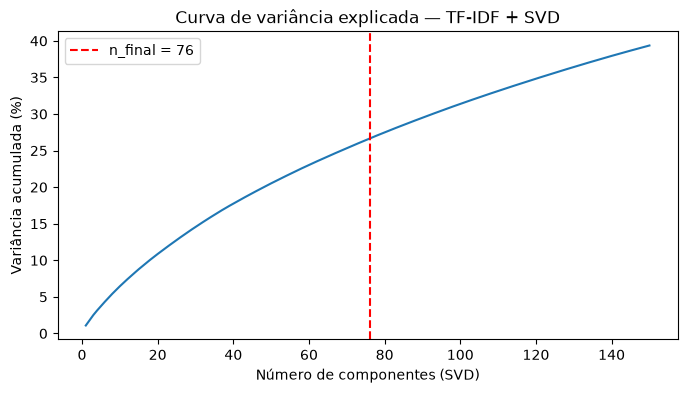

In [58]:
mask_real = ohe_df['has_description'] == 1
textos_reais = ohe_df.loc[mask_real, 'description']

print(f"Total de linhas: {len(ohe_df)}")
print(f"Linhas com descrição real: {mask_real.sum()}")
print(f"Linhas com 'missing_description': {(~mask_real).sum()}")

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(textos_reais)

svd_test = TruncatedSVD(n_components=150, random_state=42)
svd_test.fit(tfidf_matrix)

variancia_individual = svd_test.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_individual)

print(f"\nVariância acumulada com 150 componentes: {variancia_acumulada[-1]*100:.2f}%")
print("(Mostrando que mesmo 150 componentes não chegam perto de 80%)\n")

LIMIAR_GANHO_RELATIVO = 0.20
ganho_relativo = variancia_individual / variancia_individual[0]

condicao_cotovelo = ganho_relativo <= LIMIAR_GANHO_RELATIVO
if np.any(condicao_cotovelo):
    n_ideal = np.argmax(condicao_cotovelo) + 1
else:
    n_ideal = len(variancia_individual)

TETO_COMPONENTES = 100  # teto de segurança / custo computacional
n_final = min(n_ideal, TETO_COMPONENTES)

print(f"Componente onde o ganho marginal cai abaixo de {LIMIAR_GANHO_RELATIVO*100:.0f}% do 1º: {n_ideal}")
print(f"Variância acumulada nesse ponto: {variancia_acumulada[n_final-1]*100:.2f}%")
print(f"Componentes finais (com teto de segurança): {n_final}")

# Gráfico para visualizar o cotovelo
plt.figure(figsize=(8,4))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada*100)
plt.axvline(n_final, color='red', linestyle='--', label=f'n_final = {n_final}')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Variância acumulada (%)')
plt.title('Curva de variância explicada — TF-IDF + SVD')
plt.legend()
plt.show()

In [59]:
def vectorize_descriptions(df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    print("[Texto] Iniciando a vetorização das descrições...")
    
    mask_real = df['has_description'] == 1
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = tfidf.fit_transform(df.loc[mask_real, 'description'])
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    text_vectors_real = svd.fit_transform(tfidf_matrix)
    
    col_names = [f"desc_topic_{i}" for i in range(n_components)]
    
    text_vectors_full = np.zeros((len(df), n_components))
    text_vectors_full[mask_real.values] = text_vectors_real
    
    df_text = pd.DataFrame(text_vectors_full, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_text], axis=1)
    df.drop(columns=['description'], inplace=True)
    
    print(f"[Texto] Descrições vetorizadas e reduzidas para {n_components} componentes principais.")
    return df

vectorized_df = vectorize_descriptions(ohe_df, n_components=n_final)

[Texto] Iniciando a vetorização das descrições...
[Texto] Descrições vetorizadas e reduzidas para 76 componentes principais.


In [60]:
vectorized_df.info(True)

<class 'pandas.DataFrame'>
Index: 25367 entries, 0 to 151828
Data columns (total 203 columns):
 #    Column                             Dtype  
---   ------                             -----  
 0    title                              str    
 1    geek_rating                        float64
 2    min_suggested_age                  int64  
 3    complexity                         float64
 4    min_players                        int64  
 5    max_players                        int64  
 6    min_time                           int64  
 7    max_time                           int64  
 8    has_description                    int64  
 9    min_suggested_age_is_missing       int64  
 10   time_is_missing                    int64  
 11   publisher_freq                     float64
 12   cat_Abstract Strategy              int64  
 13   cat_Action                         int64  
 14   cat_Adventure                      int64  
 15   cat_Ancient                        int64  
 16   cat_Animals      

In [61]:
vectorized_df.drop(["title", "publisher_freq"], axis=1, inplace=True)

In [62]:
vectorized_df.to_csv("bgg_dataset_tratado.csv", index=False)